In [2]:
import pandas as pd
import numpy as np
import ast
from sklearn.cluster import SpectralCoclustering
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
# 1. Load the dataset
df = pd.read_csv('data_preprocessed/XWines_Slim_1K_wines_enriched.csv')

def replace_and_deduplicate(x):
    try:
        # Evaluate the stringified list
        items = ast.literal_eval(x)
        # Replace 'Appetizer' with 'Aperitif'
        updated = ['Aperitif' if item == 'Appetizer' else item for item in items]
        # Remove any duplicates while preserving order
        deduplicated = list(dict.fromkeys(updated))
        return deduplicated
    except:
        return []

df['Harmonize'] = df['Harmonize'].apply(replace_and_deduplicate)

# Safe eval for lists stored as strings in the CSV
# def parse_list(x):
#     try:
#         return ast.literal_eval(x)
#     except:
#         return []

# df['Harmonize'] = df['Harmonize'].apply(parse_list)
df['Grapes'] = df['Grapes'].apply(parse_list)

df['Harmonize'] = df['Harmonize'].replace({
    'Appetizer': 'Aperitif',
    'Dessert': 'Dessert_food'
})

# 2. Bin ABV into categories to make it a categorical feature
df['ABV_Bin'] = pd.cut(df['ABV'], bins=[0, 11, 13.5, 100], labels=['Low_ABV', 'Medium_ABV', 'High_ABV'])

# Explode on Harmonize to make it easier to link each food to the wine features
df_exploded = df.explode('Harmonize')


# Identify top 30 grapes to keep the matrix dense and meaningful
all_grapes = pd.Series([g for sublist in df['Grapes'] for g in sublist])
top_grapes = set(all_grapes.value_counts().head(30).index)

In [33]:
# 3. Create a mapping of Wine Features vs. Food Pairings
features_list = []
for idx, row in df_exploded.iterrows():
    food = row['Harmonize']
    # Add Type
    features_list.append((food, f"Type_{row['Type']}"))
    # Add Body
    features_list.append((food, f"Body_{row['Body']}"))
    # Add Acidity
    features_list.append((food, f"Acidity_{row['Acidity']}"))
    # Add binned ABV
    features_list.append((food, str(row['ABV_Bin'])))
    # Add Grapes (if in the top 30)
    for g in row['Grapes']:
        if g in top_grapes:
            features_list.append((food, f"Grape_{g}"))

# Create a co-occurrence matrix (cross-tabulation)
df_features = pd.DataFrame(features_list, columns=['Food', 'Feature'])
cooc = pd.crosstab(df_features['Food'], df_features['Feature'])

In [34]:
features_list

[('Pork', 'Type_Sparkling'),
 ('Pork', 'Body_Medium-bodied'),
 ('Pork', 'Acidity_High'),
 ('Pork', 'Low_ABV'),
 ('Pork', 'Grape_Muscat/Moscato'),
 ('Rich Fish', 'Type_Sparkling'),
 ('Rich Fish', 'Body_Medium-bodied'),
 ('Rich Fish', 'Acidity_High'),
 ('Rich Fish', 'Low_ABV'),
 ('Rich Fish', 'Grape_Muscat/Moscato'),
 ('Shellfish', 'Type_Sparkling'),
 ('Shellfish', 'Body_Medium-bodied'),
 ('Shellfish', 'Acidity_High'),
 ('Shellfish', 'Low_ABV'),
 ('Shellfish', 'Grape_Muscat/Moscato'),
 ('Beef', 'Type_Red'),
 ('Beef', 'Body_Medium-bodied'),
 ('Beef', 'Acidity_Medium'),
 ('Beef', 'Medium_ABV'),
 ('Barbecue', 'Type_Red'),
 ('Barbecue', 'Body_Medium-bodied'),
 ('Barbecue', 'Acidity_Medium'),
 ('Barbecue', 'Medium_ABV'),
 ('Codfish', 'Type_Red'),
 ('Codfish', 'Body_Medium-bodied'),
 ('Codfish', 'Acidity_Medium'),
 ('Codfish', 'Medium_ABV'),
 ('Pasta', 'Type_Red'),
 ('Pasta', 'Body_Medium-bodied'),
 ('Pasta', 'Acidity_Medium'),
 ('Pasta', 'Medium_ABV'),
 ('Pizza', 'Type_Red'),
 ('Pizza', 'Body

Heatmap saved as 'biclustering_heatmap.png'
Cluster 1:
  Foods: Blue Cheese, Cold Cuts, Dessert, Fruit Dessert, Hard Cheese, Maturated Cheese, Salad, Sweet Dessert, Tomato Dishes
  Features: Acidity_Low, Grape_Garnacha, Grape_Touriga Nacional, Type_Dessert, Type_Rosé

Cluster 2:
  Foods: Barbecue, Beef, Codfish, French Fries, Game Meat, Ham, Lamb, Pasta, Pizza, Poultry, Veal
  Features: Acidity_High, Acidity_Medium, Body_Full-bodied, Body_Very full-bodied, Grape_Barbera, Grape_Cabernet Franc, Grape_Cabernet Sauvignon, Grape_Carignan/Cariñena, Grape_Carmenère, Grape_Gamay Noir, Grape_Grenache, Grape_Malbec, Grape_Merlot, Grape_Nebbiolo, Grape_Petit Verdot, Grape_Sangiovese, Grape_Spätburgunder, Grape_Syrah/Shiraz, Grape_Tempranillo, Grape_Zinfandel, High_ABV, Medium_ABV, Type_Red

Cluster 3:
  Foods: Cake, Chocolate, Fruit, Light Stews
  Features: Grape_Tinta Barroca, Grape_Tinta Roriz, Grape_Tinto Cão, Grape_Touriga Franca, Type_Dessert/Port

Cluster 4:
  Foods: Aperitif, Cheese, Chick

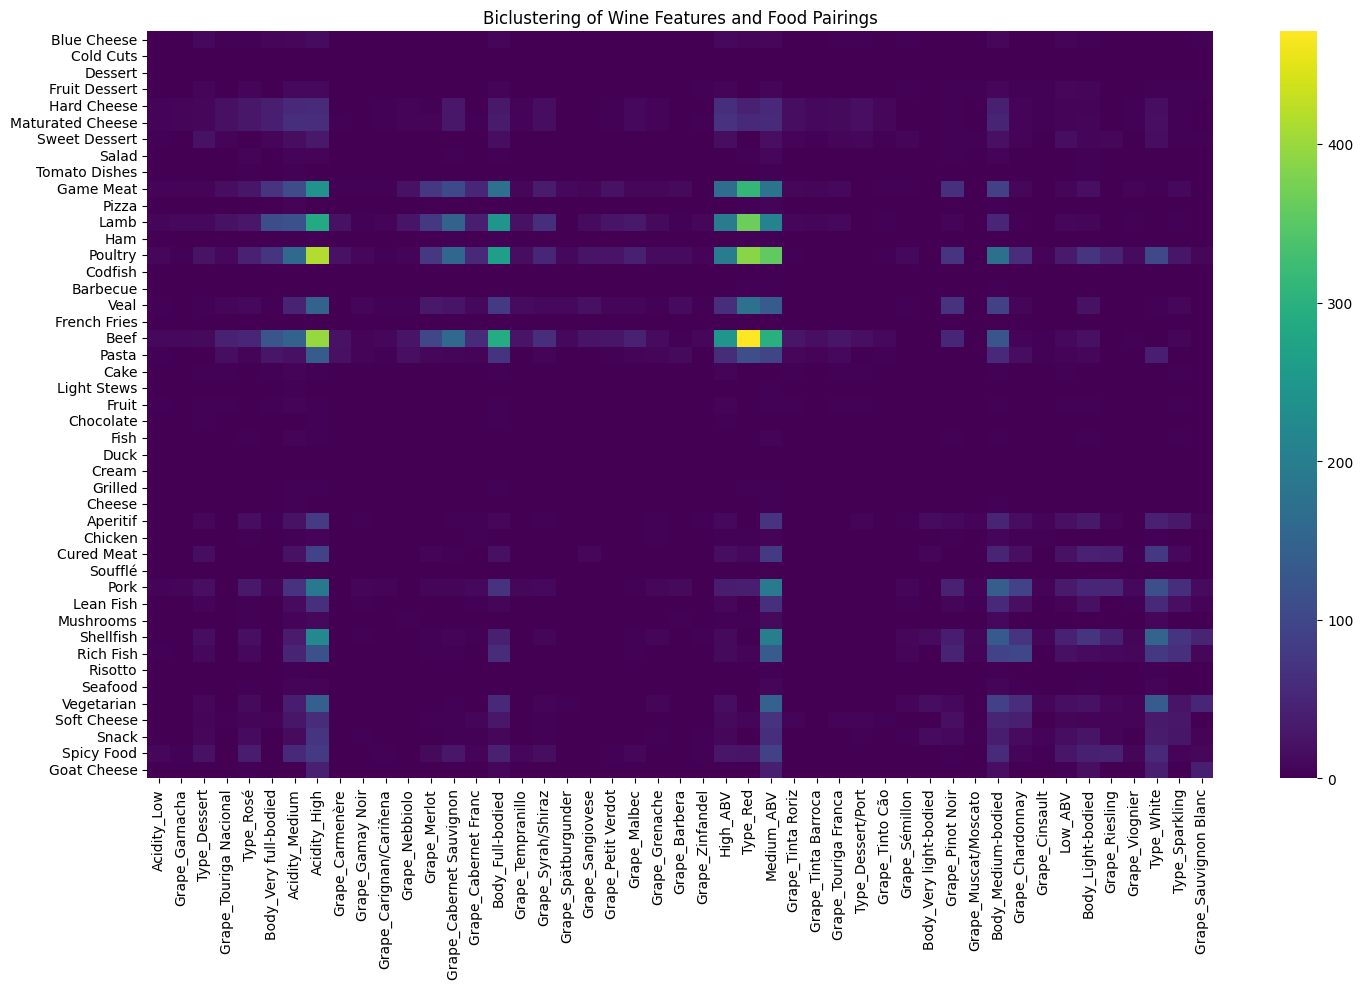

In [35]:
# 4. Run Spectral Coclustering
n_clusters = 5
model = SpectralCoclustering(n_clusters=n_clusters, random_state=42)
model.fit(cooc)

# Rearrange matrix according to the biclusters for visualization
fit_data = cooc.values[np.argsort(model.row_labels_)]
fit_data = fit_data[:, np.argsort(model.column_labels_)]

row_labels = cooc.index[np.argsort(model.row_labels_)]
col_labels = cooc.columns[np.argsort(model.column_labels_)]

# 5. Plot the clustered heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(fit_data, cmap='viridis', xticklabels=col_labels, yticklabels=row_labels)
plt.title('Biclustering of Wine Features and Food Pairings')
plt.tight_layout()
plt.savefig('biclustering_heatmap.png')
print("Heatmap saved as 'biclustering_heatmap.png'")

# 6. Extract and save the cluster assignments
clusters = []
for i in range(n_clusters):
    cluster_foods = cooc.index[model.row_labels_ == i].tolist()
    cluster_features = cooc.columns[model.column_labels_ == i].tolist()
    clusters.append({
        'Cluster': i + 1,
        'Foods': ", ".join(cluster_foods),
        'Wine_Features': ", ".join(cluster_features)
    })

df_clusters = pd.DataFrame(clusters)
df_clusters.to_csv('biclusters_summary.csv', index=False)

# Print results to the console
for _, row in df_clusters.iterrows():
    print(f"Cluster {row['Cluster']}:")
    print(f"  Foods: {row['Foods']}")
    print(f"  Features: {row['Wine_Features']}\n")

### Type, Acidity, Body only

Heatmap saved as 'biclustering_acidity_body_type.png'
Cluster 1:
  Foods: Blue Cheese, Cold Cuts, Dessert, Fruit Dessert, Hard Cheese, Maturated Cheese, Sweet Dessert, Tomato Dishes
  Features: Acidity_Low, Type_Dessert, Type_Rosé

Cluster 2:
  Foods: Aperitif, Cheese, Chicken, Cream, Cured Meat, Duck, Fish, Goat Cheese, Lean Fish, Mushrooms, Pork, Rich Fish, Risotto, Seafood, Shellfish, Snack, Soft Cheese, Soufflé, Spicy Food, Vegetarian
  Features: Body_Light-bodied, Body_Medium-bodied, Body_Very light-bodied, Type_Sparkling, Type_White

Cluster 3:
  Foods: Barbecue, Beef, Codfish, French Fries, Game Meat, Grilled, Ham, Lamb, Light Stews, Pasta, Pizza, Poultry, Salad, Veal
  Features: Acidity_High, Acidity_Medium, Body_Full-bodied, Body_Very full-bodied, Type_Red

Cluster 4:
  Foods: Cake, Chocolate, Fruit
  Features: Type_Dessert/Port



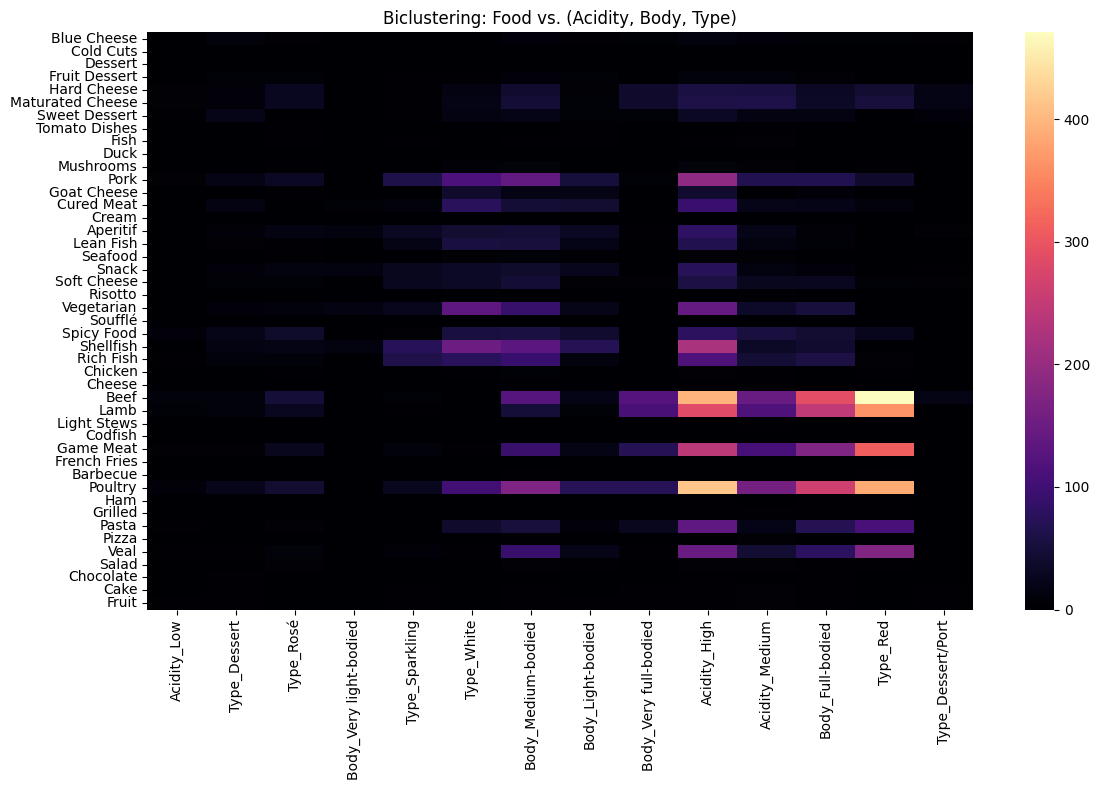

In [36]:

# Explode on Harmonize to make it easier to link each food to the wine features
df_exploded = df.explode('Harmonize').dropna(subset=['Harmonize'])

# 2. Create a mapping of ONLY Acidity, Body, and Type vs Food
features_list = []
for idx, row in df_exploded.iterrows():
    food = row['Harmonize']
    features_list.append((food, f"Type_{row['Type']}"))
    features_list.append((food, f"Body_{row['Body']}"))
    features_list.append((food, f"Acidity_{row['Acidity']}"))

# Create a co-occurrence matrix
df_features = pd.DataFrame(features_list, columns=['Food', 'Feature'])
cooc = pd.crosstab(df_features['Food'], df_features['Feature'])

# 3. Run Spectral Coclustering (4 clusters fits this perfectly)
n_clusters = 4 
model = SpectralCoclustering(n_clusters=n_clusters, random_state=42)
model.fit(cooc)

# Rearrange matrix according to the biclusters for visualization
fit_data = cooc.values[np.argsort(model.row_labels_)]
fit_data = fit_data[:, np.argsort(model.column_labels_)]

row_labels = cooc.index[np.argsort(model.row_labels_)]
col_labels = cooc.columns[np.argsort(model.column_labels_)]

# 4. Plot the clustered heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(fit_data, cmap='magma', xticklabels=col_labels, yticklabels=row_labels)
plt.title('Biclustering: Food vs. (Acidity, Body, Type)')
plt.tight_layout()
plt.savefig('biclustering_acidity_body_type.png')
print("Heatmap saved as 'biclustering_acidity_body_type.png'")

# 5. Extract and save the cluster assignments
clusters = []
for i in range(n_clusters):
    cluster_foods = cooc.index[model.row_labels_ == i].tolist()
    cluster_features = cooc.columns[model.column_labels_ == i].tolist()
    clusters.append({
        'Cluster': i + 1,
        'Foods': ", ".join(cluster_foods),
        'Wine_Features': ", ".join(cluster_features)
    })

df_clusters = pd.DataFrame(clusters)
df_clusters.to_csv('biclusters_acidity_body_type.csv', index=False)

# Print results to the console
for _, row in df_clusters.iterrows():
    print(f"Cluster {row['Cluster']}:")
    print(f"  Foods: {row['Foods']}")
    print(f"  Features: {row['Wine_Features']}\n")

## Set only

In [37]:
import pandas as pd
import ast


# Explode the dataset so each food pairing is on its own row
df_exp = df.explode('Harmonize').dropna(subset=['Harmonize'])

# 2. Build the Formal Context (Binary Incidence Matrix)
# This creates a boolean grid where Rows = Foods and Columns = Wine Features
records = []
for _, row in df_exp.iterrows():
    food = row['Harmonize']
    records.append({'Food': food, 'Feature': f"Type_{row['Type']}"})
    records.append({'Food': food, 'Feature': f"Body_{row['Body']}"})
    records.append({'Food': food, 'Feature': f"Acidity_{row['Acidity']}"})

df_feat = pd.DataFrame(records)
# Crosstab creates the binary matrix (True if the food pairs with the feature, False otherwise)
context = pd.crosstab(df_feat['Food'], df_feat['Feature']) > 0

# 3. Formal Concept Analysis (Symbolic Biclustering) using pure Set Theory
# Step 3a: Get the initial object intents (the specific set of features each food has)
object_intents = [frozenset(context.columns[row]) for _, row in context.iterrows()]

# Step 3b: Build the lattice of closed intents via intersections
# (A closed intent is a maximal set of features shared by a group of foods)
closed_intents = set(object_intents)
while True:
    new_intents = set(closed_intents)
    # Intersect every intent with every other intent to find shared features
    for c1 in closed_intents:
        for c2 in closed_intents:
            new_intents.add(c1.intersection(c2))
    
    # If no new intersections are found, our lattice is mathematically "closed"
    if len(new_intents) == len(closed_intents):
        break
    closed_intents = new_intents

# Step 3c: Map the closed intents back to their extents (the foods that share them)
concepts = []
for intent in closed_intents:
    intent_list = sorted(list(intent))
    
    if len(intent_list) > 0:
        # The Extent is the exact list of foods that have ALL attributes in this intent
        extent = context.index[context[intent_list].all(axis=1)].tolist()
        
        # Filter for meaningful concepts (e.g., at least 3 foods and 2 features)
        if len(extent) >= 3 and len(intent_list) >= 2: 
            concepts.append({
                'Support': len(extent),
                'Intent (Wine Features)': ", ".join(intent_list),
                'Extent (Food Group)': ", ".join(extent),
                'Intent_Size': len(intent_list)
            })

# 4. Format and Display the Results
df_concepts = pd.DataFrame(concepts).sort_values(
    by=['Support', 'Intent_Size'], 
    ascending=[False, False]
)

# Drop redundant combinations for clean viewing
df_concepts = df_concepts.drop_duplicates(subset=['Intent (Wine Features)'])

# Print the top 12 strongest symbolic rules
print(df_concepts[['Intent (Wine Features)', 'Support', 'Extent (Food Group)']].head(12).to_string())

# Optional: Save to CSV for external analysis
df_concepts.to_csv('symbolic_biclusters.csv', index=False)

                                                  Intent (Wine Features)  Support                                                                                                                                                                                                                                                                                                                                                                       Extent (Food Group)
155                                   Acidity_Medium, Body_Medium-bodied       38  Aperitif, Barbecue, Beef, Blue Cheese, Cake, Cheese, Chicken, Codfish, Cured Meat, Duck, Fish, Fruit, Fruit Dessert, Game Meat, Goat Cheese, Grilled, Hard Cheese, Lamb, Lean Fish, Light Stews, Maturated Cheese, Mushrooms, Pasta, Pizza, Pork, Poultry, Rich Fish, Risotto, Salad, Seafood, Shellfish, Snack, Soft Cheese, Spicy Food, Sweet Dessert, Tomato Dishes, Veal, Vegetarian
29                                     Acidity_Medium, Body_Light-bodied       3